In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
import re



In [2]:

df = pd.read_csv('lazada_all_reviews2.csv')

# Làm sạch dữ liệu
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'\d+', '', text)  # loại bỏ số
    text = re.sub(r'[^\w\s]', '', text)  # loại bỏ ký tự đặc biệt
    text = re.sub(r'\s+', ' ', text)  # loại bỏ khoảng trắng thừa
    return text.strip()

df = df.dropna(subset=['Nội dung'])
df['clean_text'] = df['Nội dung'].apply(clean_text)

# Vector hóa văn bản
vectorizer = CountVectorizer(max_df=0.95, min_df=5)
dtm = vectorizer.fit_transform(df['clean_text'])

# Áp dụng LDA
lda_model = LatentDirichletAllocation(n_components=5, random_state=42)
lda_model.fit(dtm)

# Lấy danh sách từ
feature_names = vectorizer.get_feature_names_out()

# Gợi ý tên chủ đề theo thứ tự (có thể thay đổi sau khi xem từ khóa)
topic_labels = {
    1: " Kích cỡ & độ vừa vặn",
    2: " Màu sắc & kích thước theo vóc dáng",
    3: " Giao hàng & trải nghiệm mua sắm",
    4: " Trải nghiệm tích cực & đa dạng màu",
    5: " Thiết kế thời trang & chất liệu"
}

# In ra các chủ đề kèm tên gợi ý
def print_topics_with_labels(model, feature_names, labels, n_top_words=10):
    for topic_idx, topic in enumerate(model.components_):
        top_words = [feature_names[i] for i in topic.argsort()[:-n_top_words - 1:-1]]
        label = labels.get(topic_idx + 1, f"Chủ đề {topic_idx + 1}")
        print(f"\n🔹 {label}")
        print("   Từ khóa:", ", ".join(top_words))
# Đọc file CSV
import pandas as pd
import re
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

df = pd.read_csv('lazada_all_reviews2.csv')

# Làm sạch dữ liệu
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'\d+', '', text)  # loại bỏ số
    text = re.sub(r'[^\w\s]', '', text)  # loại bỏ ký tự đặc biệt
    text = re.sub(r'\s+', ' ', text)  # loại bỏ khoảng trắng thừa
    return text.strip()

df = df.dropna(subset=['Nội dung'])
df['clean_text'] = df['Nội dung'].apply(clean_text)

# Vector hóa văn bản
vectorizer = CountVectorizer(max_df=0.95, min_df=5)
dtm = vectorizer.fit_transform(df['clean_text'])

# Áp dụng LDA
lda_model = LatentDirichletAllocation(n_components=5, random_state=42)
lda_model.fit(dtm)

# Lấy danh sách từ
feature_names = vectorizer.get_feature_names_out()

# Gợi ý tên chủ đề theo thứ tự (có thể thay đổi sau khi xem từ khóa)
topic_labels = {
    1: " Kích cỡ & độ vừa vặn",
    2: " Màu sắc & kích thước theo vóc dáng",
    3: " Giao hàng & trải nghiệm mua sắm",
    4: " Trải nghiệm tích cực & đa dạng màu",
    5: " Thiết kế thời trang & chất liệu"
}

# In ra các chủ đề kèm tên gợi ý
def print_topics_with_labels(model, feature_names, labels, n_top_words=10):
    for topic_idx, topic in enumerate(model.components_):
        top_words = [feature_names[i] for i in topic.argsort()[:-n_top_words - 1:-1]]
        label = labels.get(topic_idx + 1, f"Chủ đề {topic_idx + 1}")
        print(f"\n🔹 {label}")
        print("   Từ khóa:", ", ".join(top_words))


# Gọi hàm in
print_topics_with_labels(lda_model, feature_names, topic_labels)



🔹  Kích cỡ & độ vừa vặn
   Từ khóa: ok, áo, với, mặc, size, hơi, vải, hợp, vừa, mỏng

🔹  Màu sắc & kích thước theo vóc dáng
   Từ khóa: kích, chất, kiểu, màu, chiều, cacân, cỡ, good, vừa, ok

🔹  Giao hàng & trải nghiệm mua sắm
   Từ khóa: hàng, đẹp, shop, áo, giao, mua, rất, nhanh, đúng, chất

🔹  Trải nghiệm tích cực & đa dạng màu
   Từ khóa: cho, và, tuyệt, vời, hảo, hoàn, trang, sắc, màu, nhiều

🔹  Thiết kế thời trang & chất liệu
   Từ khóa: và, chất, thoải, mái, thời, liệu, thiết, kế, áo, trang


C:\Users\Nguyen Khanh Duong\AppData\Local\Temp\ipykernel_5700\2156475738.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=topic_counts.values, y=topic_labels, palette="Set2")


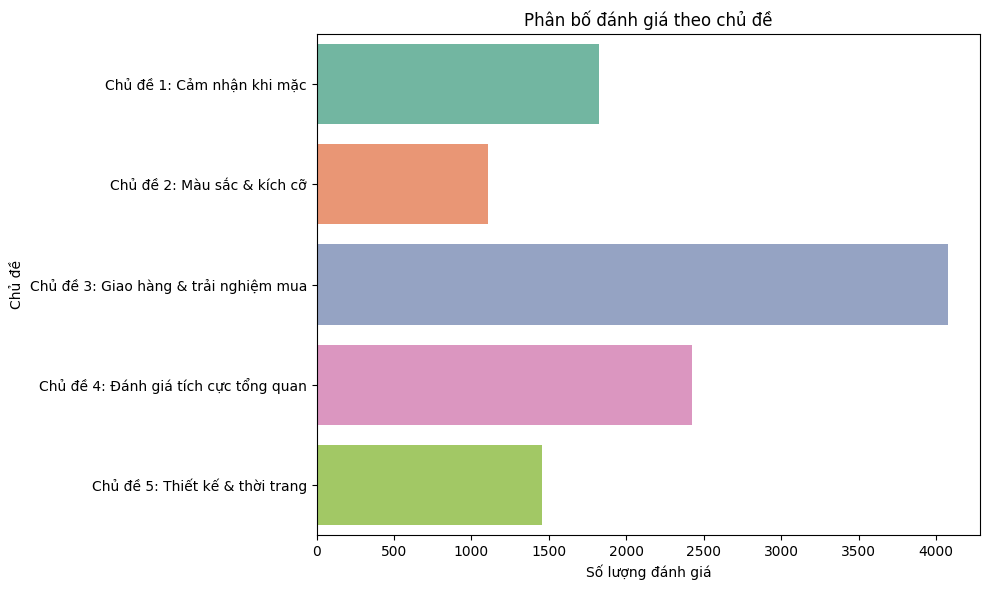

In [3]:


# Hàm làm sạch văn bản
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

# B1: Đọc và lọc dữ liệu có "Nội dung"
df = pd.read_csv("lazada_all_reviews2.csv")  # hoặc đường dẫn khác nếu cần
df_cleaned = df.dropna(subset=["Nội dung"]).copy()
df_cleaned["clean_text"] = df_cleaned["Nội dung"].apply(clean_text)

# B2: Vector hóa
vectorizer = CountVectorizer(max_df=0.95, min_df=5)
dtm = vectorizer.fit_transform(df_cleaned["clean_text"])

# B3: Huấn luyện LDA
lda_model = LatentDirichletAllocation(n_components=5, random_state=42)
lda_model.fit(dtm)

# B4: Gán topic
topic_distributions = lda_model.transform(dtm)
df_cleaned["Topic"] = topic_distributions.argmax(axis=1) + 1

# B5: Đặt tên gợi ý cho các topic
suggested_topic_names = {
    1: "Cảm nhận khi mặc",
    2: "Màu sắc & kích cỡ",
    3: "Giao hàng & trải nghiệm mua",
    4: "Đánh giá tích cực tổng quan",
    5: "Thiết kế & thời trang"
}

# B6: Vẽ biểu đồ
topic_counts = df_cleaned['Topic'].value_counts().sort_index()
topic_labels = [f"Chủ đề {i}: {suggested_topic_names[i]}" for i in topic_counts.index]

plt.figure(figsize=(10, 6))
sns.barplot(x=topic_counts.values, y=topic_labels, palette="Set2")
plt.title("Phân bố đánh giá theo chủ đề")
plt.xlabel("Số lượng đánh giá")
plt.ylabel("Chủ đề")
plt.tight_layout()
plt.savefig("topic_distribution.png")
plt.show()





C:\Users\Nguyen Khanh Duong\AppData\Local\Temp\ipykernel_2764\990018187.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Size_Gom', data=df_size,order=df_size['Size_Gom'].value_counts().index,palette='deep')


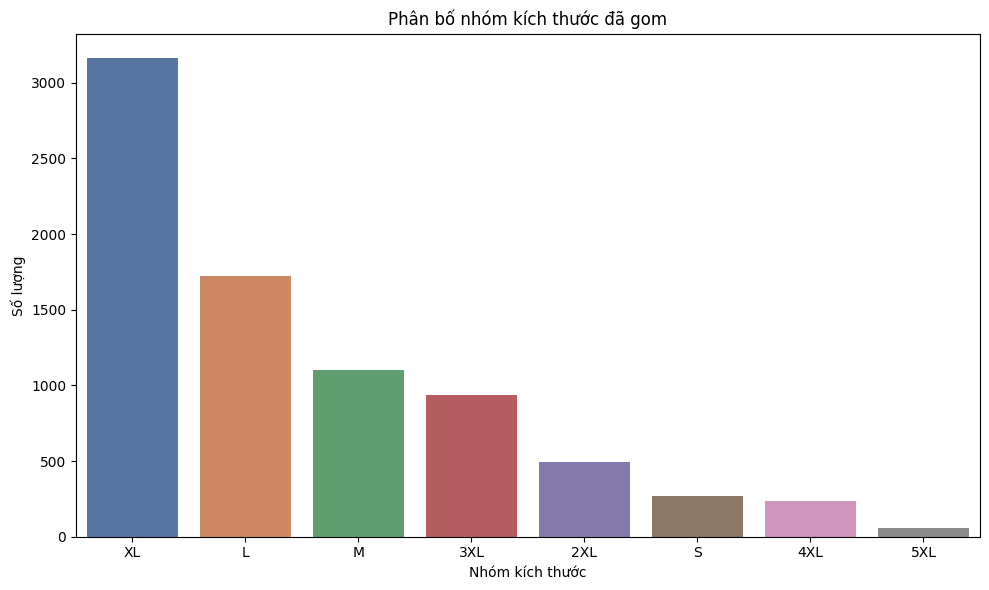

In [ ]:
# Gom nhóm các size gần giống lại với nhau
def gom_nhom_size(size):
    if pd.isna(size):
        return 'Khác'

    size = size.upper()

    # Gom nhóm theo các từ khóa chính
    if 'S' in size and not any(x in size for x in ['M', 'L', 'XL']):
        return 'S'
    elif 'M' in size and not any(x in size for x in ['L', 'XL']):
        return 'M'
    elif 'L' in size and not 'XL' in size:
        return 'L'
    elif 'XL' in size and not any(x in size for x in ['2XL', '3XL', '4XL', '5XL']):
        return 'XL'
    elif '2XL' in size or 'XXL' in size:
        return '2XL'
    elif '3XL' in size or 'XXXL' in size:
        return '3XL'
    elif '4XL' in size:
        return '4XL'
    elif '5XL' in size:
        return '5XL'
    else:
        return 'Khác'

# Áp dụng hàm gom nhóm
df_size['Size_Gom'] = df_size['Size'].apply(gom_nhom_size)

# Vẽ biểu đồ các nhóm kích thước đã gom
plt.figure(figsize=(10, 6))
sns.countplot(x='Size_Gom', data=df_size,order=df_size['Size_Gom'].value_counts().index,palette='deep')  
plt.title('Phân bố nhóm kích thước ')
plt.xlabel('Nhóm kích thước')
plt.ylabel('Số lượng')
plt.tight_layout()
plt.savefig('size_grouped_distribution.png')
plt.show()


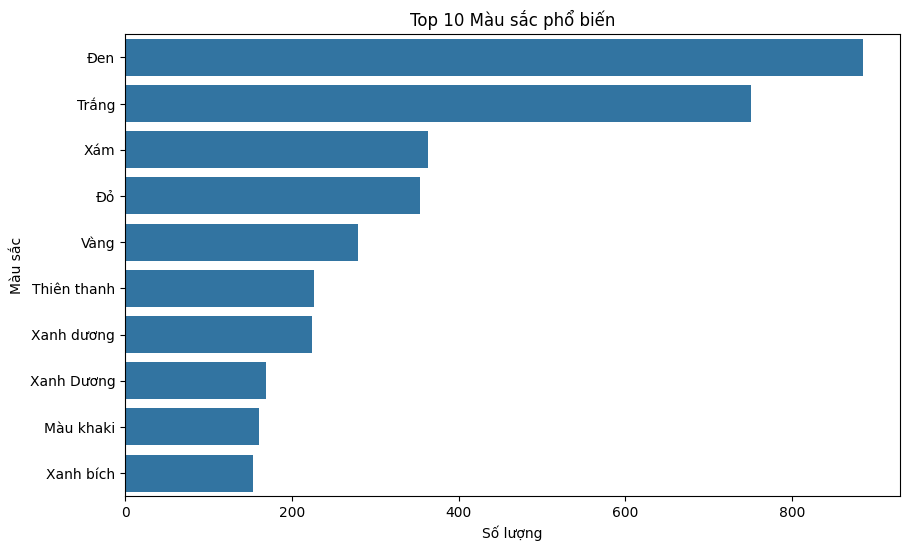

In [24]:


# Đọc dữ liệu
try:
    df = pd.read_csv('lazada_all_reviews2.csv', encoding='utf-8')
except:
    df = pd.read_csv('lazada_all_reviews2.csv', encoding='latin1')

# Hàm tách màu sắc và kích thước
def extract_color_size(variation):
    if pd.isna(variation):
        return None, None
    try:
        color = variation.split('Màu:')[1].split(',')[0].strip() if 'Màu:' in variation else None
        size = variation.split('Size:')[1].strip() if 'Size:' in variation else None
        return color, size
    except IndexError:
        return None, None

# Biểu đồ màu sắc
plt.figure(figsize=(10, 6))
sns.countplot(y='Color', data=df_color, order=df_color['Color'].value_counts().index[:10])
plt.title('Top 10 Màu sắc phổ biến')
plt.xlabel('Số lượng')
plt.ylabel('Màu sắc')
plt.savefig('color_distribution.png')
plt.show()



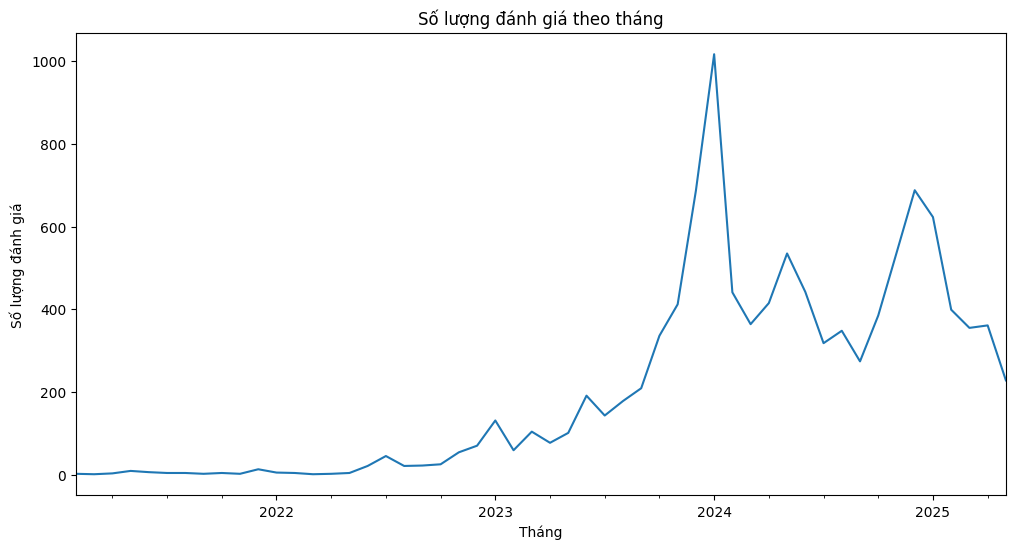

In [8]:
df = pd.read_csv('lazada_all_reviews2.csv')

# Chuyển đổi cột thời gian
df['Thời gian đánh giá'] = pd.to_datetime(df['Thời gian đánh giá'], errors='coerce')

# Nhóm theo tháng
df['Month'] = df['Thời gian đánh giá'].dt.to_period('M')
monthly_reviews = df.groupby('Month').size()

# Vẽ biểu đồ đường
plt.figure(figsize=(12, 6))
monthly_reviews.plot()
plt.title('Số lượng đánh giá theo tháng')
plt.xlabel('Tháng')
plt.ylabel('Số lượng đánh giá')
plt.savefig('monthly_reviews.png')
plt.show()